
--------------------
cos(x) at x = 0.1
--------------------
Forward
  best h found     = 7.943e-05
  smallest error   = 3.319e-04
  ~significant digits = 3.48
Central
  best h found     = 1.122e-02
  smallest error   = 7.194e-07
  ~significant digits = 6.14
Extrapolated
  best h found     = 1.122e-02
  smallest error   = 7.194e-07
  ~significant digits = 6.14


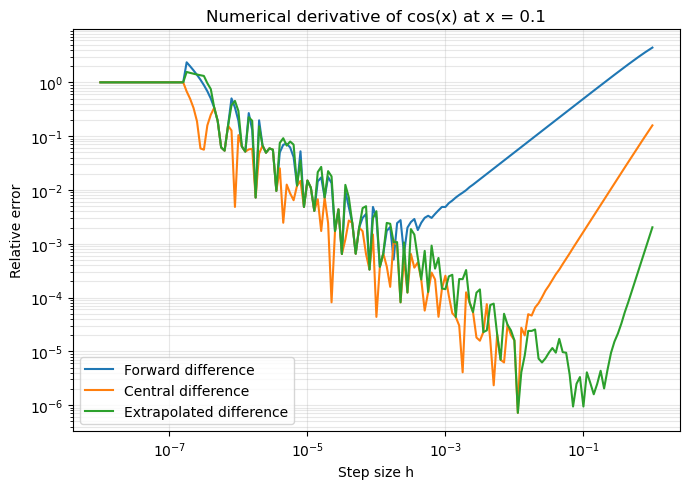


--------------------
cos(x) at x = 10.0
--------------------
Forward
  best h found     = 1.259e-04
  smallest error   = 3.601e-05
  ~significant digits = 4.44
Central
  best h found     = 1.413e-02
  smallest error   = 4.348e-06
  ~significant digits = 5.36
Extrapolated
  best h found     = 1.259e-01
  smallest error   = 8.013e-07
  ~significant digits = 6.10


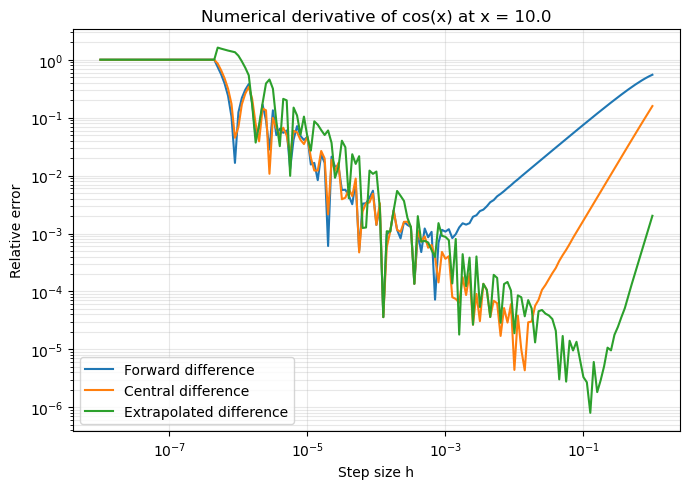


--------------------
exp(x) at x = 0.1
--------------------
Forward
  best h found     = 2.818e-04
  smallest error   = 4.621e-05
  ~significant digits = 4.34
Central
  best h found     = 3.162e-03
  smallest error   = 4.741e-07
  ~significant digits = 6.32
Extrapolated
  best h found     = 1.000e-01
  smallest error   = 6.523e-08
  ~significant digits = 7.19


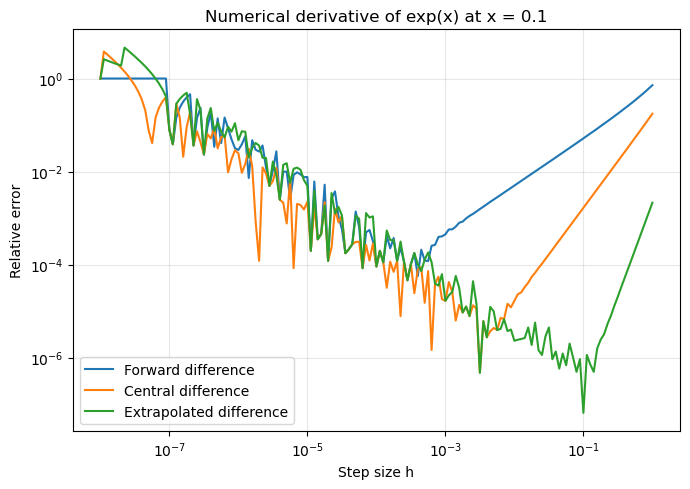


--------------------
exp(x) at x = 10.0
--------------------
Forward
  best h found     = 7.079e-04
  smallest error   = 1.326e-05
  ~significant digits = 4.88
Central
  best h found     = 1.122e-02
  smallest error   = 2.440e-06
  ~significant digits = 5.61
Extrapolated
  best h found     = 1.259e-01
  smallest error   = 1.318e-07
  ~significant digits = 6.88


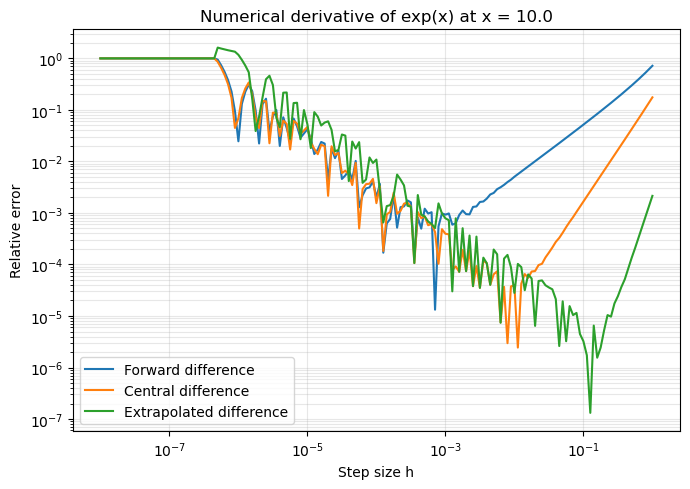

In [1]:
# ============================================================
# Single precision numerical differentiation of cos(x) and exp(x) using forward difference, central difference, extrapolated difference
# ============================================================

import numpy as np                 
import matplotlib.pyplot as plt     


# define functions:

def fn_cos(x):
    return np.float32(np.cos(np.float32(x)))      #cos(x) in single precision

def fn_exp(x):
    return np.float32(np.exp(np.float32(x)))    #e^x in single precision


# true derivatives:

def true_deriv_cos(x):
    return -np.sin(x)                           #d/dx cos(x) = -sin(x)

def true_deriv_exp(x):
    return np.exp(x)                            #d/dx e^x = e^x 


# numerical differentiation methods:

def diff_forward(func, x, h):
    #formula: (f(x+h) - f(x)) / h
    x = np.float32(x)                           #x is single precision
    h = np.float32(h)                           #h is single precision
    numerator = func(x + h) - func(x)           #numerator: change in f
    return numerator / h                   


def diff_central(func, x, h):
    #formula: (f(x+h) - f(x-h)) / (2h)
    x = np.float32(x)
    h = np.float32(h)
    numerator = func(x + h) - func(x - h)       #numerator: symmetric change in f
    denom = np.float32(2.0) * h                 #denominator: 2h
    return numerator / denom


def diff_extrapolated(func, x, h):
    h = np.float32(h)
    est_full = diff_central(func, x, h)                                     #central estimate with step h
    est_half = diff_central(func, x, np.float32(h / np.float32(2.0)))       #central estimate with step h/2
    combined = (np.float32(4.0) * est_half - est_full) / np.float32(3.0)    #formula
    return combined


# measure relative error of estimate:

def relative_error(estimate, true_value):
    #relative error = |estimate - true| / |true|
    return abs((float(estimate) - true_value) / true_value)


# sweep over step sizes and plot errors:

def study_case(func, true_deriv_func, label, x, save_file):
    #step sizes to test: 161 points spaced evenly on a log scale from 10^0 to 10^-8
    step_sizes = np.logspace(0, -8, 161, dtype=np.float32)

    true_value = true_deriv_func(x)    #the exact answer

    #empty lists that we will fill in
    err_forward = []
    err_central = []
    err_extrap = []

    for step in step_sizes:                         #trying every step size
        val_forward = diff_forward(func, x, step)
        val_central = diff_central(func, x, step)
        val_extrap = diff_extrapolated(func, x, step)

        err_forward.append(relative_error(val_forward, true_value))
        err_central.append(relative_error(val_central, true_value))
        err_extrap.append(relative_error(val_extrap, true_value))

    #turning the lists into numpy arrays so we can plot them
    err_forward = np.array(err_forward)
    err_central = np.array(err_central)
    err_extrap = np.array(err_extrap)

    #grouping results together
    all_results = {
        "Forward": err_forward,
        "Central": err_central,
        "Extrapolated": err_extrap,
    }

    #printing best step size and how many digits we trust:
    print()
    print("--------------------")
    print(f"{label} at x = {x}")
    print("--------------------")

    for method_name, err_array in all_results.items():
        best_index = np.argmin(err_array)              #position of the smallest error
        best_step = step_sizes[best_index]             #the step size that gave smallest error
        best_error = err_array[best_index]             #the smallest error itself

        #roughly how many correct decimal digits that error corresponds to
        digits_trusted = -np.log10(best_error)

        print(f"{method_name}")
        print(f"  best h found     = {best_step:.3e}")
        print(f"  smallest error   = {best_error:.3e}")
        print(f"  ~significant digits = {digits_trusted:.2f}")

    #making log-log plot of error vs step size ----
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.loglog(step_sizes, err_forward, label="Forward difference")
    ax.loglog(step_sizes, err_central, label="Central difference")
    ax.loglog(step_sizes, err_extrap, label="Extrapolated difference")

    ax.set_xlabel("Step size h")
    ax.set_ylabel("Relative error")
    ax.set_title(f"Numerical derivative of {label} at x = {x}")
    ax.legend()

    # force grid on BOTH axes explicitly — some styles/rcParams only grid the y-axis by default
    ax.xaxis.grid(True, which="both", alpha=0.3)
    ax.yaxis.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_file, dpi=200)
    plt.show()                        


#run all cases

study_case(fn_cos, true_deriv_cos, "cos(x)", 0.1, "cos_x01.png")
study_case(fn_cos, true_deriv_cos, "cos(x)", 10.0, "cos_x10.png")
study_case(fn_exp, true_deriv_exp, "exp(x)", 0.1, "exp_x01.png")
study_case(fn_exp, true_deriv_exp, "exp(x)", 10.0, "exp_x10.png")


--------------------
cos(x) at x = 0.1
--------------------
Forward
  best h found     = 7.943e-05
  smallest error   = 3.319e-04
  ~significant digits = 3.48
Central
  best h found     = 1.122e-02
  smallest error   = 7.194e-07
  ~significant digits = 6.14
Extrapolated
  best h found     = 1.122e-02
  smallest error   = 7.194e-07
  ~significant digits = 6.14


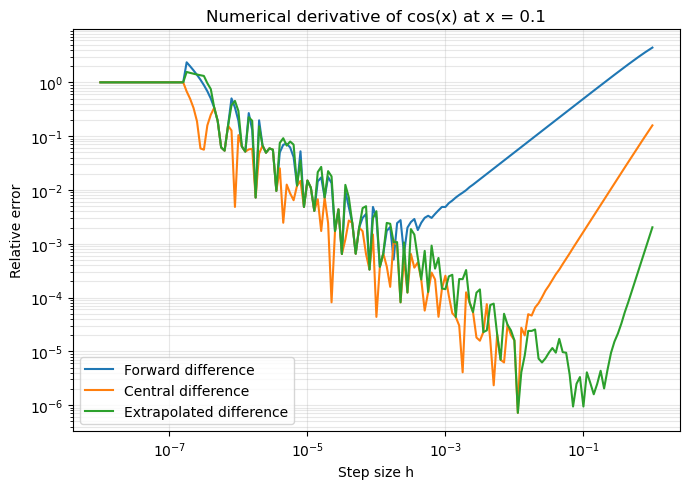


--------------------
cos(x) at x = 10.0
--------------------
Forward
  best h found     = 1.259e-04
  smallest error   = 3.601e-05
  ~significant digits = 4.44
Central
  best h found     = 1.413e-02
  smallest error   = 4.348e-06
  ~significant digits = 5.36
Extrapolated
  best h found     = 1.259e-01
  smallest error   = 8.013e-07
  ~significant digits = 6.10


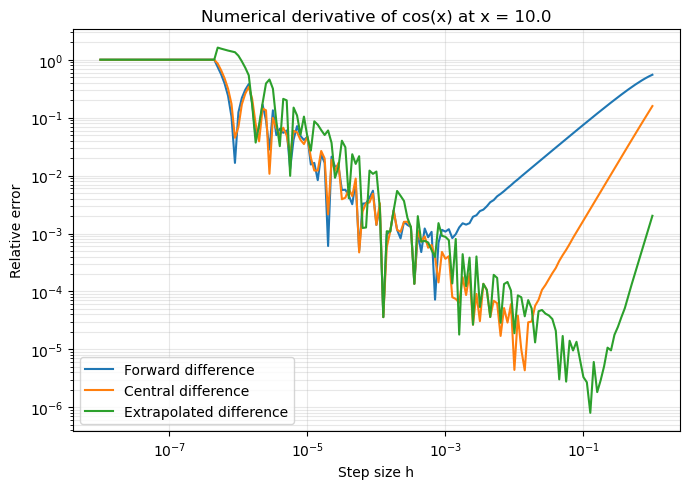


--------------------
exp(x) at x = 0.1
--------------------
Forward
  best h found     = 2.818e-04
  smallest error   = 4.621e-05
  ~significant digits = 4.34
Central
  best h found     = 3.162e-03
  smallest error   = 4.741e-07
  ~significant digits = 6.32
Extrapolated
  best h found     = 1.000e-01
  smallest error   = 6.523e-08
  ~significant digits = 7.19


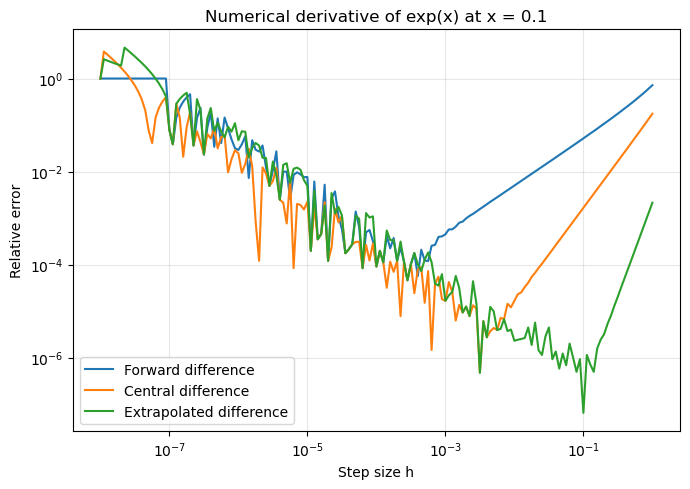


--------------------
exp(x) at x = 10.0
--------------------
Forward
  best h found     = 7.079e-04
  smallest error   = 1.326e-05
  ~significant digits = 4.88
Central
  best h found     = 1.122e-02
  smallest error   = 2.440e-06
  ~significant digits = 5.61
Extrapolated
  best h found     = 1.259e-01
  smallest error   = 1.318e-07
  ~significant digits = 6.88


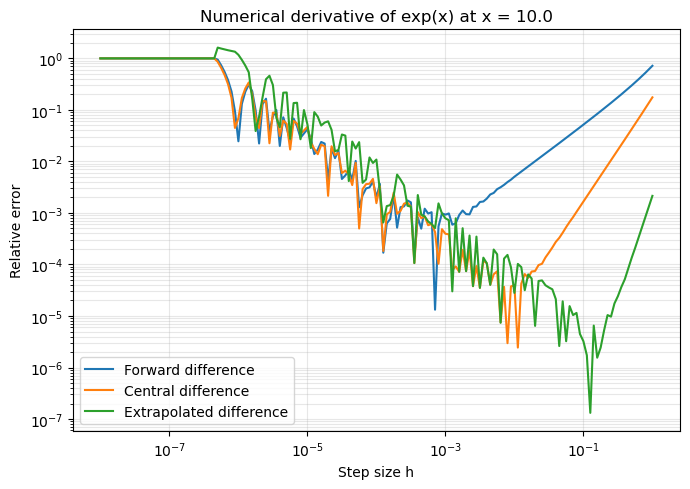

In [17]:
import numpy as np                 
import matplotlib.pyplot as plt     


def fn_cos(x):
    return np.float32(np.cos(np.float32(x)))      #cos(x) in single precision

def fn_exp(x):
    return np.float32(np.exp(np.float32(x)))      #FIXED: was np.float32(val)


def true_deriv_cos(x):
    return -np.sin(x)                              #FIXED: was np.sin(val)

def true_deriv_exp(val):
    return np.exp(val)


def diff_forward(func, x, h):
    x = np.float32(x)
    h = np.float32(h)
    numerator = func(x + h) - func(x)
    return numerator / h                   


def diff_central(func, x, h):
    x = np.float32(x)
    h = np.float32(h)
    numerator = func(x + h) - func(x - h)
    denom = np.float32(2.0) * h
    return numerator / denom


def diff_extrapolated(func, x, h):
    h = np.float32(h)
    est_full = diff_central(func, x, h)
    est_half = diff_central(func, x, np.float32(h / np.float32(2.0)))
    combined = (np.float32(4.0) * est_half - est_full) / np.float32(3.0)
    return combined


def relative_error(estimate, true_value):
    return abs((float(estimate) - true_value) / true_value)


def study_case(func, true_deriv_func, label, x, save_file):
    step_sizes = np.logspace(0, -8, 161, dtype=np.float32)
    true_value = true_deriv_func(x)

    err_forward = []
    err_central = []
    err_extrap = []

    for step in step_sizes:
        val_forward = diff_forward(func, x, step)      #FIXED: was h
        val_central = diff_central(func, x, step)       #FIXED: was h
        val_extrap = diff_extrapolated(func, x, step)    #FIXED: was h

        err_forward.append(relative_error(val_forward, true_value))
        err_central.append(relative_error(val_central, true_value))
        err_extrap.append(relative_error(val_extrap, true_value))

    err_forward = np.array(err_forward)
    err_central = np.array(err_central)
    err_extrap = np.array(err_extrap)

    all_results = {
        "Forward": err_forward,
        "Central": err_central,
        "Extrapolated": err_extrap,
    }

    print()
    print("--------------------")
    print(f"{label} at x = {x}")                       #FIXED: was x0
    print("--------------------")

    for method_name, err_array in all_results.items():
        best_index = np.argmin(err_array)
        best_step = step_sizes[best_index]
        best_error = err_array[best_index]
        digits_trusted = -np.log10(best_error)

        print(f"{method_name}")
        print(f"  best h found     = {best_step:.3e}")
        print(f"  smallest error   = {best_error:.3e}")
        print(f"  ~significant digits = {digits_trusted:.2f}")

    plt.figure(figsize=(7, 5))

    plt.loglog(step_sizes, err_forward, label="Forward difference")
    plt.loglog(step_sizes, err_central, label="Central difference")
    plt.loglog(step_sizes, err_extrap, label="Extrapolated difference")

    plt.xlabel("Step size h")
    plt.ylabel("Relative error")
    plt.title(f"Numerical derivative of {label} at x = {x}")

    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_file, dpi=200)                     #FIXED: was out_file
    plt.show()


study_case(fn_cos, true_deriv_cos, "cos(x)", 0.1, "cos_x01.png")
study_case(fn_cos, true_deriv_cos, "cos(x)", 10.0, "cos_x10.png")
study_case(fn_exp, true_deriv_exp, "exp(x)", 0.1, "exp_x01.png")
study_case(fn_exp, true_deriv_exp, "exp(x)", 10.0, "exp_x10.png")